# California Housing

## vediamo una tipica pipeline di pre-analisi di un dataset

# Passo 0: carica dataset

In [30]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing(as_frame=True)

# Access the features (X) and target (y)
df = housing.frame
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


# Passo 1: applica describe() al dataset

In [31]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Cosa controllare in un dataset dopo il describe()?

1. controllare che min e max hanno senso (AveRooms e AveOccup hanno min e max fuori scala)
2. controlla rapporto tra media e devStd. se è >1 c'è forte dispersione di dati su quella colonna (AveOccup e Population hanno dispersione)
3. controlla media e mediana (50%) sono simili tra loro. se non lo sono abbiamo una distribuzione chiamata skewed (la media è piu bassa del 50%, quindi la distribuzione dei dati è spostata piu a sx)
    come aggiustare? si raggruppano i dati in sezioni per trasformare la scala esponenziale in lineare, distribuisci in sottosezioni di lunghezza esponenziale. (piu è alta la campana in quella porzione, piu stretta sarà la porzione. piu bassa sarà la campana, piu larga sarà la sezione)
    |   |       |              |                            |
    si applica il logaritmo, cosi verranno bilanciate le distanze

    

# Passo 2: applica info()

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Cosa controllare dopo info()?

 ### 1. controllare le colonne che hanno Null (None). come li gestisco?

    - se i null < 5% rimuovo le righe nulle. sono molto poche, non le gestisco, le rimuovo e basta
    - se i null < 15%/20%, sostituisco con media i numeri e moda le stringhe
    - se i null > 20% o elimino la colonna o creo un modello di ML per predirne i valori

### Sostituzione con media 

immaginiamo un dataset con età e guadagno. ho il 10% di null sul guadagno. come faccio?
raggruppo in fasce d'età, faccio la media per fasce e sostituisco le medie dei guadagni al posto dei null per fascia d'età associata.
se c'è un valore che mi aiuta a raffruppare, meglio questo approccio che fare la media su tutta la colonna guadangno. rispecchia meglio la realtà.


### 2. controllare le colonne che non sono numeri (non possiamo fare operazioni se sono stringhe)

### 3. gestire gli outliers

possono essere di 2 tipi:
- statistici (es. persona alta 2,30 metri, raro ma plausibile)
- errori (es. persona alta 23 metri. errore)

(continua a leggere per la gestione)



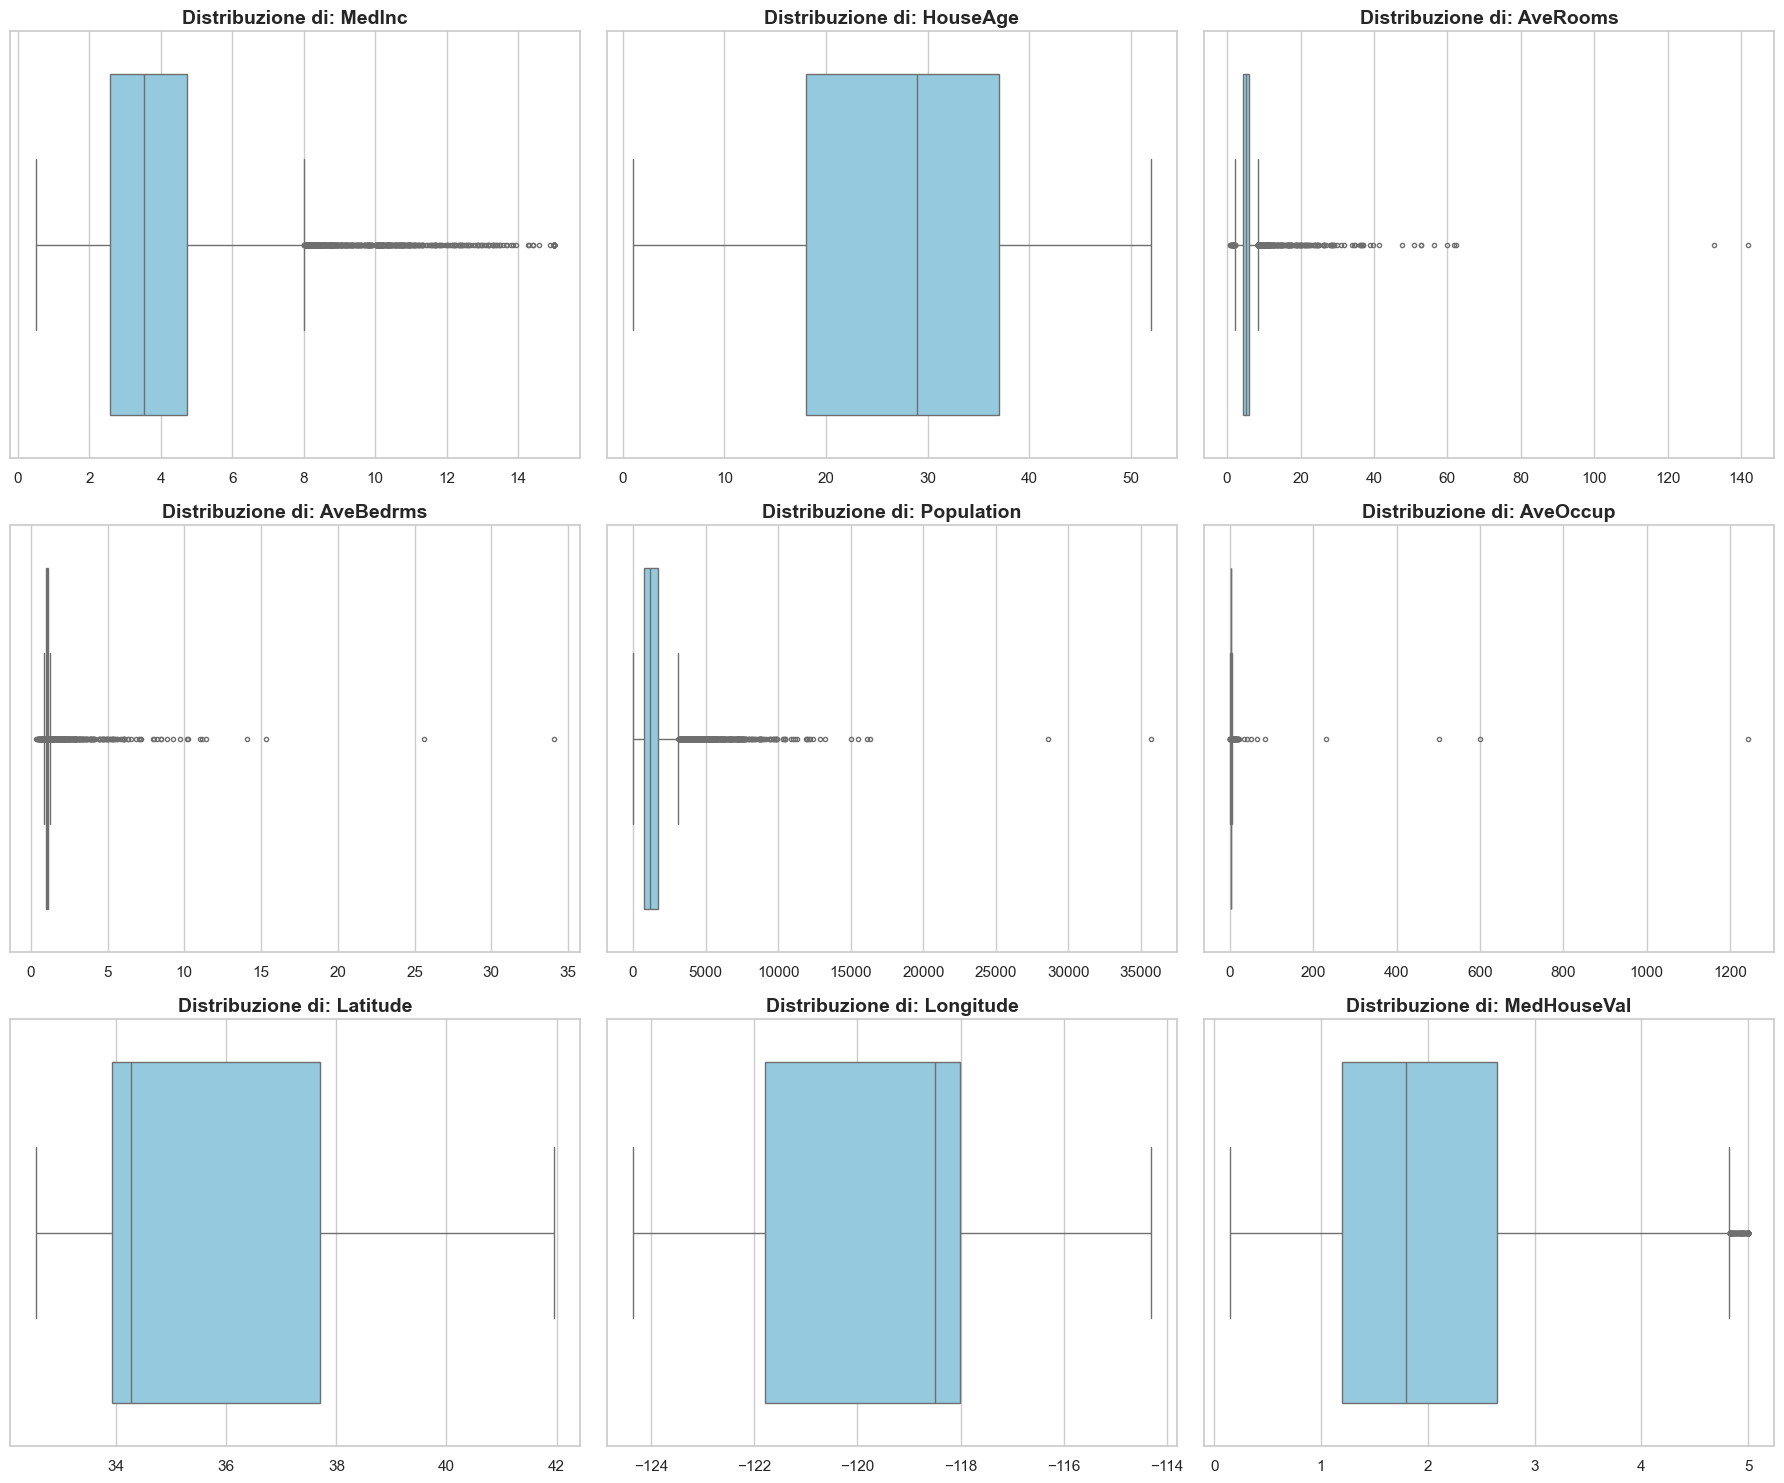

In [33]:
# Grafico BoxPlot. leggi descrizione per saperne di più
"""
BoxPlot. 
Individuare gli outlier è una fase fondamentale dell’analisi esplorativa dei dati (EDA).
Un outlier è un’osservazione che si discosta in modo significativo dal comportamento
generale del dataset.

Trovare questi valori serve principalmente a tre scopi:

1) Qualità del dato
   Un valore anomalo può essere il risultato di un errore di misurazione,
   di inserimento o di acquisizione.

2) Comprensione del fenomeno
   A volte l’outlier rappresenta un evento raro ma reale,
   che può avere un significato importante (ad esempio case di lusso
   in un dataset immobiliare).

3) Impatto sui modelli statistici
   Molti algoritmi (come regressione lineare, media e varianza)
   sono sensibili ai valori estremi. Pochi punti molto grandi o molto piccoli
   possono alterare significativamente i risultati.

Il boxplot è uno strumento grafico che permette di visualizzare in modo
sintetico la distribuzione di una variabile numerica.

Un boxplot mostra:

- La mediana (linea centrale nella scatola), che rappresenta il valore centrale.
- Il primo e terzo quartile (Q1 e Q3), che delimitano il 50% centrale dei dati.
- L’intervallo interquartile (IQR = Q3 - Q1), che misura la dispersione.
- I "baffi", che indicano l’estensione dei valori non anomali.
- Eventuali punti isolati, che rappresentano gli outlier.

Interpretare un boxplot significa osservare:

- La posizione della mediana → indica il valore tipico.
- La dimensione della scatola → misura la variabilità.
- La simmetria o asimmetria → suggerisce se la distribuzione è sbilanciata.
- La presenza di punti esterni → indica possibili valori anomali.

In sintesi, trovare gli outlier aiuta a comprendere meglio la struttura dei dati
e a decidere se mantenerli, correggerli o trattarli con tecniche specifiche.
Il boxplot fornisce una rappresentazione compatta e immediata di queste informazioni,
rendendolo uno strumento molto efficace nella fase iniziale dell’analisi.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo lo stile
sns.set_theme(style="whitegrid")

# Creiamo la griglia di subplot (3x3 adattabile)
num_colonne = len(df.columns)
righe = 3
colonne = 3

fig, axes = plt.subplots(nrows=righe, ncols=colonne, figsize=(18, 15))
axes = axes.flatten()

# Creazione boxplot per ogni colonna numerica
for i, col in enumerate(df.columns):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color='skyblue',
        fliersize=3
    )
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuove eventuali subplot vuoti se le colonne sono meno di 9
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Passo 3: gestione outlier

## 1. Metodo IQR (Interquartile Range)

È la tecnica usata dai boxplot. Si basa sulla distanza tra il primo quartile ($Q_1$) e il terzo quartile ($Q_3$). Tutto ciò che cade fuori dall'intervallo $[Q_1 - 1.5 \times IQR, Q_3 + 1.5 \times IQR]$ viene considerato outlier.


In [34]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Caricamento dati
df = fetch_california_housing(as_frame=True).frame

def remove_outliers_iqr(data, columns):
    df_clean = data.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filtraggio
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Applichiamolo solo ad alcune colonne critiche (es. MedInc e AveRooms)
df_iqr = remove_outliers_iqr(df, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Righe rimosse con IQR: {len(df) - len(df_iqr)}")

Righe rimosse con IQR: 711


## 2. Metodo Z-Score (Deviazione Standard)

Questa tecnica si basa sulla distribuzione normale. Si calcola quanto un valore dista dalla media in termini di deviazioni standard ($\sigma$). La formula dello Z-score è:

$$Z = \frac{x - \mu}{\sigma}$$

Solitamente, un valore con uno Z-score maggiore di 3 o minore di -3 è considerato un outlier estremo (rappresenta meno dello 0.3% dei dati in una distribuzione normale).


In [35]:
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
df_zscore = remove_outliers_zscore(df, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")

Righe rimosse con Z-Score: 482


## nota
IGR è più aggressivo ma funziona bene anche su distribuzioni più sporche

Z-SCORE meno aggressivo ma funziona solo su dati distribuiti normalmente

# Passo 4: gestione colonne categoriche

- se la colonna è bianria (si/no) -> trasformiamo in 0/1
- se ho più variabili (Milano/Roma/Napoli) -> assegno ad ogni variabile un numero (Milano=1, Roma=2, Napoli=3)
ma potrebbe esserci il problema che con la nuova configurazione per il computer Milano+Roma=Napoli ...
non posso quindi applicarla su variabili scollegate 

se avessi piccolo/medio/grande che hanno un rapporto di grandezza potrei farlo, ma se sono scollegate (come le città) devo procedere diversamente

SOLUZIONE: creo una colonna binaria per ogni opzione! 
- is_Milano: true/false 
- is_Roma: true/false

Attenzione! se ho 100 opzioni, sto aggiungendo 100 dimensioni. potrebbe sembrare controproducente, ma meglio avere dimensioni piu che dati incosistenti

ci sono 2 tecniche per questi approcci

## 1. Label Encoding

Il LabelEncoder trasforma le stringhe in numeri progressivi ($0, 1, 2, ...$).

In [36]:
from sklearn.preprocessing import LabelEncoder

# Esempio: Target con tre classi
y = ['Basso', 'Medio', 'Alto', 'Basso', 'Alto']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Classi originali: {le.classes_}")
print(f"Valori trasformati: {y_encoded}")
# Output: [1, 2, 0, 1, 0] (l'ordine è spesso alfabetico)

Classi originali: ['Alto' 'Basso' 'Medio']
Valori trasformati: [1 2 0 1 0]


## 2. One-Hot Encoding

Questa è la tecnica standard per le variabili categoriche senza un ordine intrinseco (es. "Colore", "Città"). Crea una nuova colonna binaria ($0$ o $1$) per ogni categoria.

In [37]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# DataFrame di esempio
df_test = pd.DataFrame({'Città': ['Roma', 'Milano', 'Napoli', 'Roma']})

# Inizializziamo l'encoder
# sparse_output=False serve per avere un array NumPy leggibile (non una matrice sparsa)
ohe = OneHotEncoder(sparse_output=False)

# Trasformazione
ohe_transformed = ohe.fit_transform(df_test[['Città']])

# Creiamo un nuovo DataFrame con i nomi delle colonne corretti
df_ohe = pd.DataFrame(ohe_transformed, columns=ohe.get_feature_names_out(['Città']))

print(df_ohe)

   Città_Milano  Città_Napoli  Città_Roma
0           0.0           0.0         1.0
1           1.0           0.0         0.0
2           0.0           1.0         0.0
3           0.0           0.0         1.0


# Passo 5: distribuzioni incrociate

## visualizzo le distribuzioni delle colonne

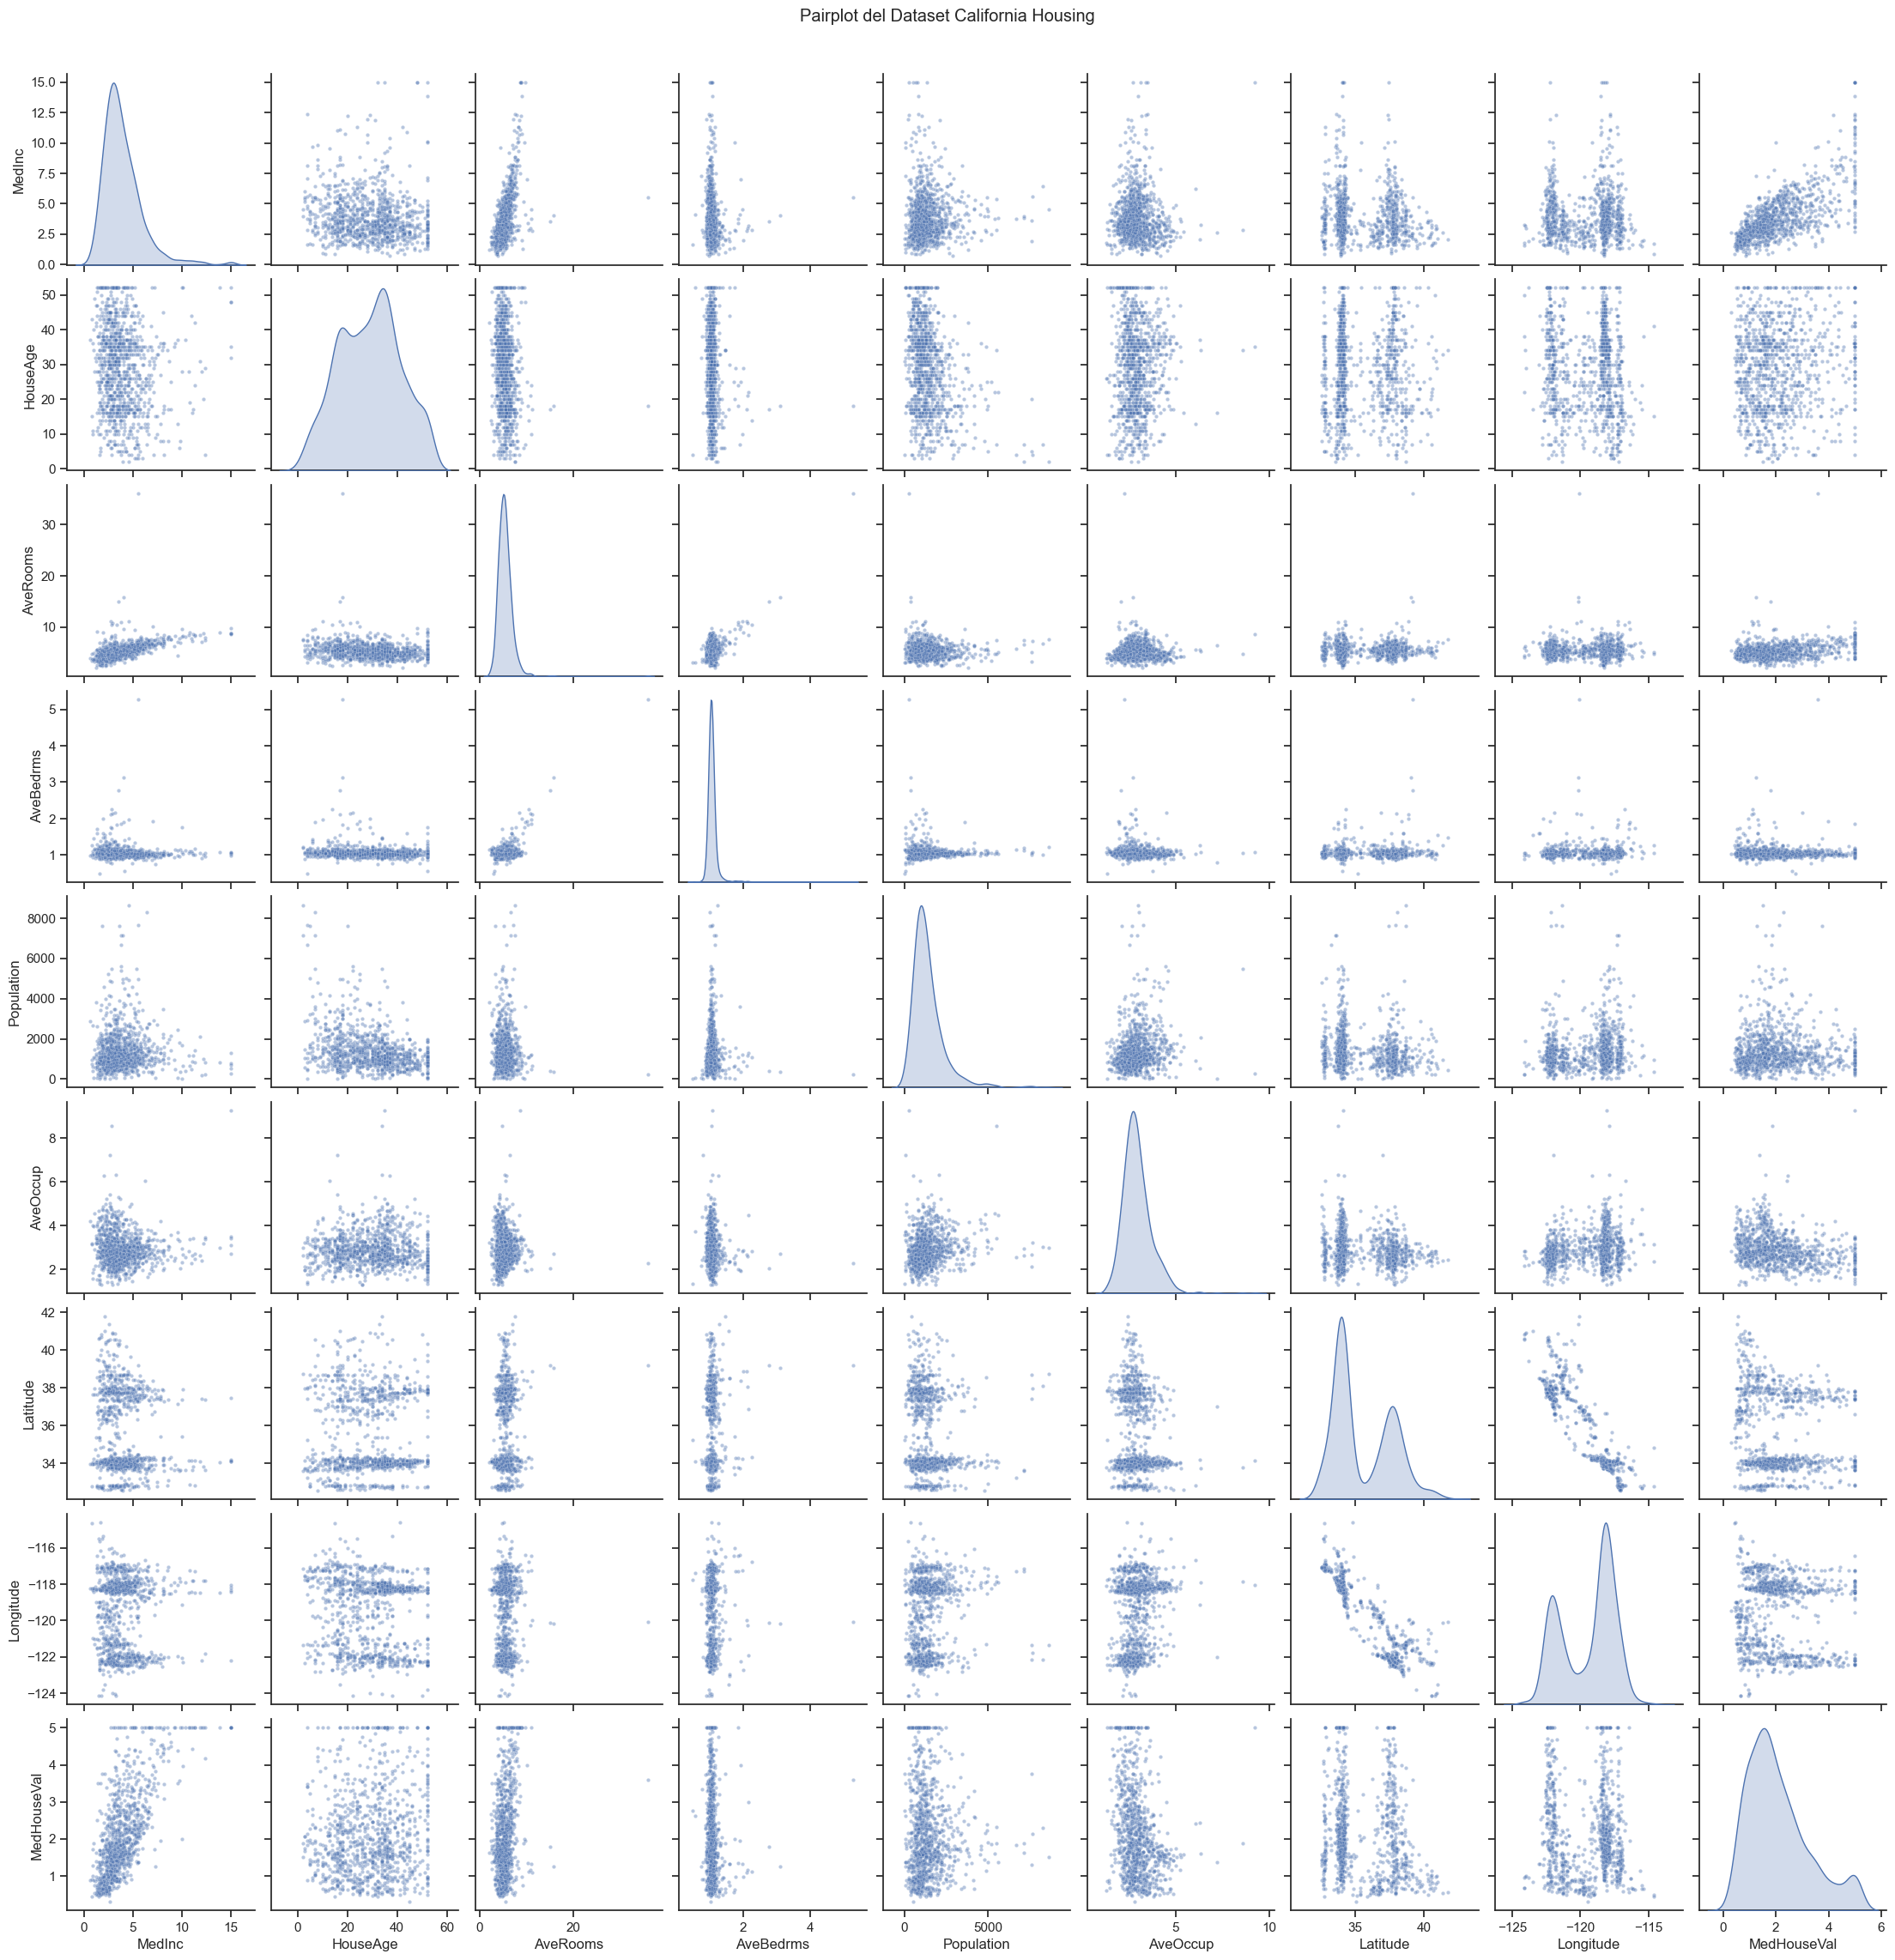

In [39]:
# Campionamento per velocità e chiarezza (es. 1000 righe)
df_sample = df.sample(n=1000, random_state=42)

# Creazione del Pairplot
# 'diag_kind' imposta i grafici sulla diagonale (istogrammi o densità KDE)
# 'plot_kws' serve per rimpicciolire i punti e renderli trasparenti
sns.pairplot(df_sample,
diag_kind='kde',
plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset California Housing", y=1.02)
plt.show()

## come interpreto? 

la diagonale è la distribuzione di se stessa, vediamo che alcune sono skewed, altre normali, altre doppie ecc 

- cerco casi di linearità, cerco tra le distribuzioni una forma "lineare" cosi so che quella riga e quella colonna sono linearmente dipendenti (se una aumenta, aumenta anche l'altra)

esempi
- vedo che MedHouseVal è linearmente dipendente da diverse colonne (quelle con una forma che ricorda una linea)
- vedo varibili lineari tra loro, soprattutto tra var Target e MedHouseVal
- vedo distribuzioni gaussiane, anche un po skewed, a cui applicherò una trasformazione logaritmica
- vedo il gradico tra lat e long e vedo (a parte la forma uguale alla california giustamente) picchi dovuti a San Francisco e Los Angeles

## Matrice di Correlazione

ottima per trovare variabili linearmente dipendenti tra loro 

sono interessanti tutte le correlazioni maggiori di +0.15 e inferiori a -0.15

ricorda:
- correlazione positiva -> andamenti simili (se una sale, l'altra sale)
- correlazione negativa -> andamenti opposti (se una sale, l'altra scende)

ATTENZIONE: correlazione non è causalità. 

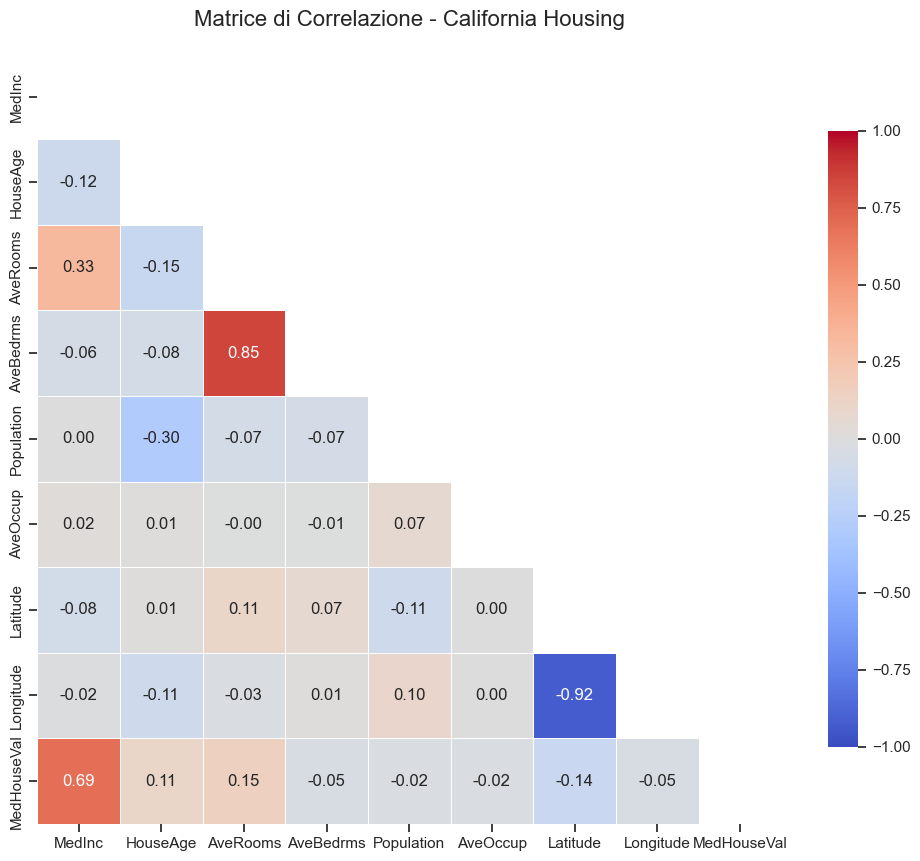

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo della matrice di correlazione
# Usiamo il metodo di Pearson (default)
corr = df.corr()

# 2. Creazione di una "maschera" per nascondere la parte superiore
# Essendo la matrice speculare, vedere entrambi i lati crea solo confusione visiva
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Configurazione del grafico
plt.figure(figsize=(12, 10))

# Disegniamo la heatmap
sns.heatmap(
    corr, 
    mask=mask,          # Nasconde la parte superiore duplicata
    annot=True,         # Scrive i numeri dentro i quadratini
    fmt=".2f",          # Formatta i numeri a 2 decimali
    cmap='coolwarm',    # Colore: rosso (positivo), blu (negativo), bianco (zero)
    vmin=-1, vmax=1,    # Imposta i limiti della scala colorata
    center=0,           # Il centro della scala è lo zero
    linewidths=.5,      # Aggiunge una linea di separazione tra i quadrati
    cbar_kws={"shrink": .8} # Rimpicciolisce la barra dei colori laterale
)

plt.title('Matrice di Correlazione - California Housing', fontsize=16, pad=20)
plt.show()

## Variabili non correlate linearmente o con tanti oulier?

la correlazione di Spearman è un altro tipo di misurazione, per correlazioni non lineari

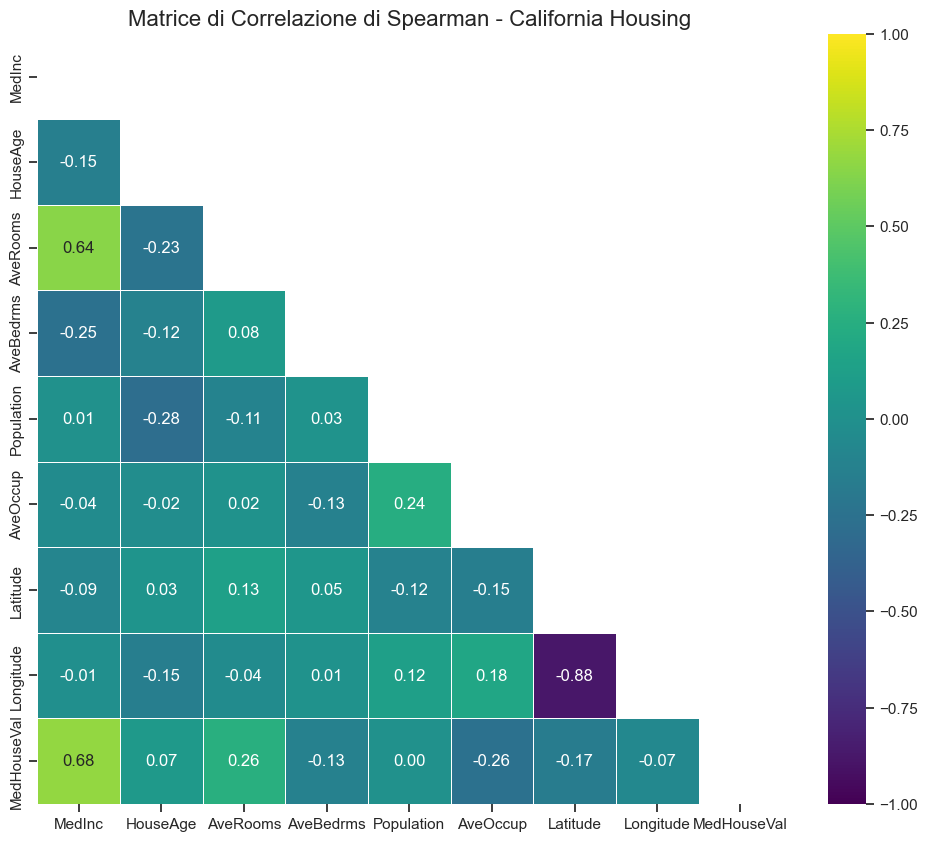

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calcolo della matrice di Spearman
# Basta cambiare il parametro 'method'
corr_spearman = df.corr(method='spearman')

# Creazione della maschera (per pulizia visiva)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# Visualizzazione
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_spearman, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='viridis',    # Cambio colore per distinguerla dalla Pearson
    vmin=-1, vmax=1, 
    center=0,
    linewidths=.5
)

plt.title('Matrice di Correlazione di Spearman - California Housing', fontsize=16)
plt.show()

# Passo 6: feature engineering

crea nuove frature come combinazioni o modifiche interessanti di feature esistenti. per esempio
- creare raggruppamenti su variabili continue (es. su  HouseAge, 1 gruppo ogni 5 anni e vedere se ci sono pattern oppure soglie di valore per MedInc per definire soglie di ceto basso, medio, ricco per vedere se cambiano alcuni pattern)
- variabili come divisione di feature esistenti (AveOccup/AveRooms, case con tot stanze per tot persone fa cambiare i prezzi)
- variabili al quadrato per eventuali relazioni non lineari (vedendo la matrice di sperman potrei provare ad usare AveRooms al quadrato)
- variabili derivare da conoscenza del settore, soprattutto in casi medici (con altezza e peso, posso vedere l'indice di massa corporea ad esempio, per info medice)

Correlazione di Spearman con il Target (MedHouseVal):
MedHouseVal         1.000000
Income_Class        0.625628
AveRooms_Squared    0.263367
HouseAge_Group      0.075584
Occup_per_Room     -0.399798
Name: MedHouseVal, dtype: float64


C:\Users\ilari\AppData\Local\Temp\ipykernel_38064\2585107523.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Income_Class', y='MedHouseVal', palette='viridis')


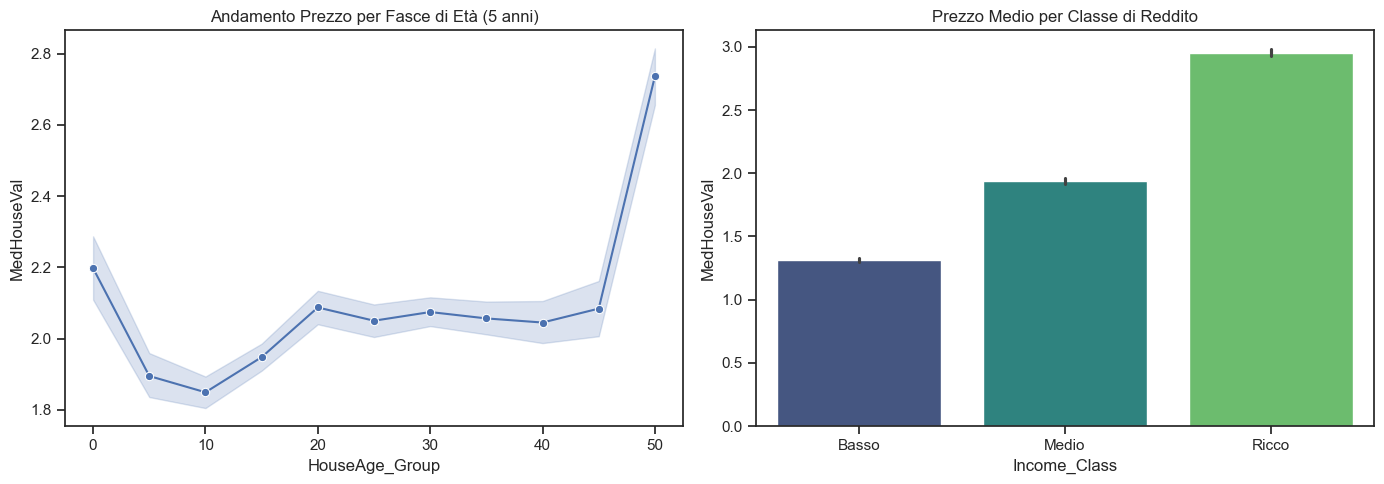

In [42]:
# --- FEATURE ENGINEERING ---

# A. Raggruppamento HouseAge (ogni 5 anni)
# Creiamo etichette numeriche basate sul limite inferiore del gruppo (0, 5, 10...)
df['HouseAge_Group'] = pd.cut(df['HouseAge'], 
                              bins=range(0, 56, 5), 
                              labels=range(0, 55, 5)).astype(float)

# B. Soglie di valore su MedInc (Ceto Basso, Medio, Ricco)
# Usiamo i quartili per definire le classi in modo bilanciato
df['Income_Class'] = pd.qcut(df['MedInc'], q=3, labels=[1, 2, 3]) 
# 1: Basso, 2: Medio, 3: Ricco (manteniamo numerico per la correlazione)

# C. Rapporto tra feature esistenti (Affollamento per stanza)
# Un valore alto indica potenzialmente zone più povere o popolose
df['Occup_per_Room'] = df['AveOccup'] / df['AveRooms']

# D. Variabile al quadrato (Relazione non lineare per AveRooms)
df['AveRooms_Squared'] = df['AveRooms'] ** 2

# --- CALCOLO CORRELAZIONI ---

# Selezioniamo le nuove feature e il target
new_features = ['HouseAge_Group', 'Income_Class', 'Occup_per_Room', 'AveRooms_Squared', 'MedHouseVal']
corr_matrix = df[new_features].astype(float).corr(method='spearman')

print("Correlazione di Spearman con il Target (MedHouseVal):")
print(corr_matrix['MedHouseVal'].sort_values(ascending=False))

# --- VISUALIZZAZIONE PATTERN ---

plt.figure(figsize=(14, 5))

# Plot 1: Andamento Prezzo vs Età Casa (Binned)
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='HouseAge_Group', y='MedHouseVal', marker='o')
plt.title('Andamento Prezzo per Fasce di Età (5 anni)')

# Plot 2: Prezzo Medio per Classe di Reddito
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Income_Class', y='MedHouseVal', palette='viridis')
plt.xticks([0, 1, 2], ['Basso', 'Medio', 'Ricco'])
plt.title('Prezzo Medio per Classe di Reddito')

plt.tight_layout()
plt.show()

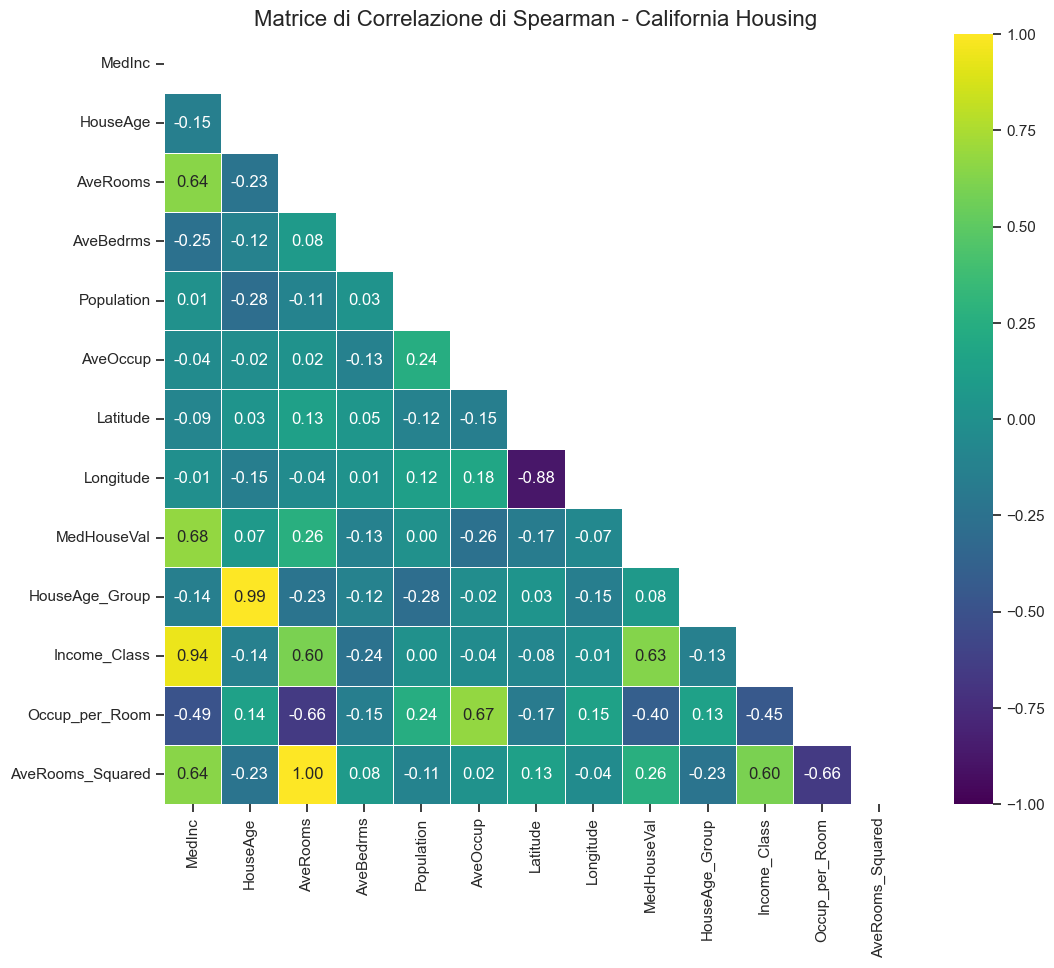

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo della matrice di Spearman
# Basta cambiare il parametro 'method'
corr_spearman = df.corr(method='spearman')

# 2. Creazione della maschera (per pulizia visiva)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# 3. Visualizzazione
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_spearman, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='viridis',    # Cambio colore per distinguerla dalla Pearson
    vmin=-1, vmax=1, 
    center=0,
    linewidths=.5
)

plt.title('Matrice di Correlazione di Spearman - California Housing', fontsize=16)
plt.show()

# Passo 7: normalizzazione

bisogna normalizzare i dati per evitare che valori enormi come 5mln per i prezzi vadano ad annientare valori piu piccoli come il numero di stanze nelle case

se devo minimizzare un errore e cambiando due valori ottengo

- un errore piu basso di 2 punti sul numero di stanze (media 5.5)
- un errore piu basso di 1000 euro sul valore di una cassa (2 mlm)

il miglior miglioramento, con un approccio relativo, è quello sul numero di istanze, ma matematicamente parlando 1000 è meglio di 2, dobbiamo evitare questa confusione al modello

ci sono 2 tecniche



## 1. MinMaxScaler (Normalizzazione)

Trasforma i dati in un intervallo fisso, solitamente **[0, 1]**.


$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

* **Pro:** Mantiene esattamente la relazione tra i dati.
* **Contro:** È **estremamente sensibile agli outlier**. Se hai un solo valore enorme (es. una casa con 100 stanze), schiaccerà tutti gli altri valori vicini allo zero.

## 2. StandardScaler (Standardizzazione)

Trasforma i dati in modo che abbiano **Media = 0** e **Deviazione Standard = 1**.


$$z = \frac{x - \mu}{\sigma}$$

* **Pro:** È più robusto in presenza di outlier rispetto al Min-Max e rende i coefficienti dei modelli lineari più facili da interpretare.
* **Contro:** Non garantisce un range fisso (i valori possono andare oltre -3 o +3).

Tranne rare eccezioni di base si usa sempre lo standardScaler. (eccezioni per le immagini, dove i pixel vanno da 0 a 255)

In [45]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.datasets import fetch_california_housing

# 1. Prepariamo i dati
data = fetch_california_housing(as_frame=True)
X = data.frame[['MedInc', 'HouseAge', 'Population']] # Prendiamo 3 variabili con scale diverse

# 2. Inizializziamo gli Scaler
min_max = MinMaxScaler()
standard = StandardScaler()

# 3. Trasformazione
X_minmax = min_max.fit_transform(X)
X_standard = standard.fit_transform(X)

# Creiamo un DataFrame per confrontare i risultati sulla prima riga
comparison = pd.DataFrame({
    'Originale': X.iloc[0],
    'Min-Max [0, 1]': X_minmax[0],
    'Standard (z-score)': X_standard[0]
})

print("Confronto Scaler sulla prima riga del dataset:")
print(comparison)

Confronto Scaler sulla prima riga del dataset:
            Originale  Min-Max [0, 1]  Standard (z-score)
MedInc         8.3252        0.539668            2.344766
HouseAge      41.0000        0.784314            0.982143
Population   322.0000        0.008941           -0.974429
